# What the phasing lever actually costs

`BudgetPhaser`'s `max_weekly_deviation_pct` is the number a media planner signs off: "you may move any week's spend by up to ±X%." This notebook asks two questions about it that the other notebooks cannot answer.

**First, how much of X actually reaches the model?** The shipped draw picks each week's nudge uniformly from the whole band, and the mean absolute value of a uniform draw is only *half* its range. So a ±20% permission moves a typical week by far less than 20%, and most of what was negotiated is never spent. `nudge_shape` and `balance_signs` exist to change that, and section 2 measures what the difference is worth.

**Second, what does using more of the band cost?** Every other notebook in this repo measures phasing against a truth that is **linear in spend**, where moving money between weeks inside a month is free by construction: the month's total is preserved, so its contribution to revenue is unchanged. Real response curves saturate. Under any concave curve, spreading the same monthly budget more unevenly produces **less** revenue — Jensen's inequality, exact, no assumption beyond concavity itself. That is the cost axis, and sections 3–5 put numbers on it.

The headline result is in section 5, and it is not the one the package currently tells: **all-Blackout, which `docs/overview.html` uses as its headline scenario, is the most expensive way to buy reliability on offer.**

**Scope.** Everything here phases **TV alone**, with Meta and Search left exactly as planned, so gain and cost are measured on the same channel under the same schedule. `CollinearityDiagnostic` is unchanged and still fits OLS linear in spend — the concave response in sections 3–5 is defined locally in this notebook, not added to the package DGP. Extending the DGP itself is the separate piece of work the omitted-variable-bias question needs.

In [1]:
FAST_MODE = False  # set True for a quick structural run, False for real numbers

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from how_wrong_is_your_mmm import Blackout, BudgetPhaser, simulate_spend
from how_wrong_is_your_mmm._phaser import (
    _generate_phased_schedule,
    _get_month_labels,
)

N_SIMS = 10 if FAST_MODE else 50
N_PHASING_SEEDS = 2 if FAST_MODE else 8
N_DRAW_SEEDS = 20 if FAST_MODE else 200  # for distributional summaries

## The data

The canonical scenario used throughout the repo: four years of correlated history plus a 52-week plan year, correlation 0.7, and the illustrative marginal returns `docs/overview.html` publishes.

In [3]:
history = simulate_spend(n_obs=208, correlation=0.7, seed=0, start_date="2019-01-07")
plan = simulate_spend(n_obs=52, correlation=0.7, seed=1, start_date="2023-01-09")
month_labels = _get_month_labels(plan)
true_marginal_returns = {"tv": 0.5, "meta": 1.0, "search": 1.5}

CHANNEL = "tv"
plan_spend = plan[CHANNEL].to_numpy()

print(
    f"Plan year: {plan.shape[0]} weeks, {len(np.unique(month_labels))} monthly groups"
)
print(
    f"{CHANNEL.upper()}: £{plan_spend.sum() / 1e6:.2f}m planned, "
    f"mean £{plan_spend.mean():,.0f}/week, "
    f"range £{plan_spend.min():,.0f}-£{plan_spend.max():,.0f}"
)

Plan year: 52 weeks, 13 monthly groups
TV: £5.10m planned, mean £98,031/week, range £41,257-£149,756


## 1. How much of the negotiated band reaches the model?

`max_weekly_deviation_pct` caps the **draw**, before the monthly rescale. Two things then shrink what actually lands:

1. A uniform draw's mean absolute value is half its cap.
2. The rescale divides the month through by its own mean deviation, removing whatever common shift the draw happened to contain.

`nudge_shape` changes the first (`"annulus"` draws from the outer half of the band, `"edge"` sits on the cap) and `balance_signs` changes the second (equal up and down weeks per month, so there is almost nothing to divide out).

Averaged over independent schedule draws, since one draw is noisy.

In [4]:
def realised_deviation(nominal_pct, nudge_shape, balance_signs, n_seeds=N_DRAW_SEEDS):
    """Realised |weekly deviation| from plan for CHANNEL, in percent."""
    spec = {ch: (nominal_pct if ch == CHANNEL else 0.0) for ch in plan.columns}
    means, worsts = [], []
    for seed in range(n_seeds):
        sched = _generate_phased_schedule(
            plan,
            month_labels,
            alpha=1.0,
            max_weekly_deviation_pct=spec,
            seed=seed,
            nudge_shape=nudge_shape,
            balance_signs=balance_signs,
        )
        dev = np.abs((sched[CHANNEL].to_numpy() - plan_spend) / plan_spend) * 100
        means.append(dev.mean())
        worsts.append(dev.max())
    return float(np.mean(means)), float(np.max(worsts))


SHAPES = [
    ("uniform", False, "uniform (ships today)"),
    ("uniform", True, "uniform + balanced"),
    ("annulus", False, "annulus"),
    ("annulus", True, "annulus + balanced"),
    ("edge", False, "edge"),
    ("edge", True, "edge + balanced"),
]

rows = []
for nominal in (20.0, 40.0, 80.0):
    for shape, balanced, label in SHAPES:
        mean_dev, worst_dev = realised_deviation(nominal, shape, balanced)
        rows.append(
            {
                "nominal": f"±{nominal:.0f}%",
                "scheme": label,
                "mean |dev|": round(mean_dev, 1),
                "share of band used": round(mean_dev / nominal, 2),
                "worst |dev|": round(worst_dev, 1),
                "worst as ×nominal": round(worst_dev / nominal, 2),
            }
        )

band_usage = pd.DataFrame(rows)
print(band_usage.to_string(index=False))

nominal                scheme  mean |dev|  share of band used  worst |dev|  worst as ×nominal
   ±20% uniform (ships today)         8.3                0.41         32.9               1.65
   ±20%    uniform + balanced         9.4                0.47         29.4               1.47
   ±20%               annulus        11.4                0.57         37.1               1.86
   ±20%    annulus + balanced        13.9                0.70         28.3               1.42
   ±20%                  edge        15.0                0.75         43.1               2.16
   ±20%       edge + balanced        18.5                0.93         27.2               1.36
   ±40% uniform (ships today)        16.7                0.42         74.6               1.86
   ±40%    uniform + balanced        18.9                0.47         65.6               1.64
   ±40%               annulus        23.2                0.58         87.4               2.19
   ±40%    annulus + balanced        27.9                0.7

**The shipped draw spends about 40% of what was negotiated.** At a ±20% permission the typical week moves ~8%; at ±80%, ~35%. The `share of band used` column is the whole argument for the option existing.

**`balance_signs` is what makes the aggressive shapes safe, and it is not a small effect.** Look at `worst as ×nominal`. Unbalanced, `edge` at ±80% drives some week to several times its planned spend, because a month that happens to draw three weeks down forces the surviving week to absorb the entire month. Balanced, the same shape is *better contained than the shipped uniform draw*, because a sign-balanced month has almost nothing for the rescale to divide out.

So the honest pairing is `annulus` or `edge` **with** `balance_signs=True`. Used alone they trade an overshoot for the extra variation; used together they do not.

One caveat that matters for reading everything below: the cap binds on the draw, not on the realised deviation. Nothing here enforces a hard ceiling on what a week actually ends up spending. A genuinely hard external constraint — an ad platform's ±20% ceiling, say — would need a repair step after the rescale that the package does not have.

## 2. What the extra variation buys

`channel_sensitivity` sweeps one channel's own lever from 0% to the nominal maximum with the other channels left on plan, and reports the coefficient of variation of the estimated marginal return. Lower CV is a tighter estimate.

The `Blackout` row is the on/off lever — full spend some weeks, £0 others, at most one dark week a month. It is unaffected by `nudge_shape` by construction, so it appears identically in every column and acts as a control.

In [5]:
def gain_curve(nudge_shape, balance_signs):
    phaser = BudgetPhaser(
        history_df=history,
        plan_df=plan,
        true_marginal_returns=true_marginal_returns,
        max_weekly_deviation_pct=80.0,
        nudge_shape=nudge_shape,
        balance_signs=balance_signs,
    )
    cv = phaser.channel_sensitivity(
        CHANNEL,
        alphas=[0, 0.25, 0.5, 0.75, 1.0],
        magnitude_pct=80.0,
        blackout=Blackout(max_dark_weeks_per_month=1),
        n_sims=N_SIMS,
        n_phasing_seeds=N_PHASING_SEEDS,
        fast_mode=FAST_MODE,
    ).set_index("label")["cv"]
    return 100 * (1 - cv / cv.loc["0%"])


GAIN_SCHEMES = [
    ("uniform", False, "uniform (ships today)"),
    ("annulus", True, "annulus + balanced"),
    ("edge", True, "edge + balanced"),
]
gain = pd.DataFrame(
    {label: gain_curve(shape, bal) for shape, bal, label in GAIN_SCHEMES}
)
print("% narrower than unphased, TV")
print(gain.round(1).to_string())

% narrower than unphased, TV
          uniform (ships today)  annulus + balanced  edge + balanced
label                                                               
0%                          0.0                 0.0              0.0
20%                         4.2                 9.4             14.0
40%                        14.0                25.7             36.8
60%                        30.0                38.9             53.3
80%                        37.3                54.1             64.5
Blackout                   56.7                54.4             54.4


**Three to four times the gain, at the same setting the planner signed off.** TV at ±20% goes from 4.2 points to 14.0; at ±40%, from 14.0 to 36.8.

**And `edge + balanced` at ±80% beats all-Blackout — with no dark weeks at all.** That reframes a claim the package has been making. `Blackout` is inherently an edge draw: every week is either full spend or zero. It was the only lever already using its whole band, and it was being compared against a continuous lever that was sampling timidly inside its own. Level that up and Blackout's advantage disappears.

Two things on the page rest on the old comparison and will need revisiting: `chartLever`'s caption ("the on/off switch is worth another 12 to 19 points on top of the strongest continuous setting") and the choice of all-Blackout as the headline scenario running through sections 4 and 5. Going dark on TV is the hardest ask on the page. Section 5 shows it is also the worst-value one.

**Do not act on this section alone.** Everything above is measured against a truth linear in spend, where more variation is free. Sections 3 to 5 are the check.

## 3. Does the gain survive a saturating truth?

The concern with pushing a lever to its edge is that spend then sits at only a couple of distinct levels, and a model cannot see the *shape* of a response curve through two points. If that bit, aggressive phasing would buy precision and lose accuracy.

Define a concave truth for TV, calibrated so its marginal return at the planned spend level equals the 0.5 the rest of the repo assumes:

$$\text{contribution}(x) = k\,x^{b}, \qquad k = \frac{mr_0}{b\,x_0^{\,b-1}}$$

with $b<1$ giving diminishing returns, $x_0$ the mean planned weekly spend and $mr_0 = 0.5$. Then fit OLS **linear in spend**, which is what `CollinearityDiagnostic` does, and compare the recovered slope against the true marginal return at the plan.

In [6]:
X0 = float(plan_spend.mean())
MR0 = true_marginal_returns[CHANNEL]


def concave_truth(x, b):
    """Contribution with diminishing returns, marginal return MR0 at X0."""
    k = MR0 / (b * X0 ** (b - 1.0))
    return k * np.asarray(x, dtype=float) ** b


NOISE_SD = 0.12 * concave_truth(X0, 0.6)


def estimate_marginal_return(
    nominal_pct, nudge_shape, balance_signs, b, n_seeds=N_DRAW_SEEDS
):
    """OLS slope of revenue on spend -- what a linear MMM recovers."""
    spec = {ch: (nominal_pct if ch == CHANNEL else 0.0) for ch in plan.columns}
    slopes = []
    for seed in range(n_seeds):
        if nominal_pct == 0.0:
            spend = plan_spend
        else:
            spend = _generate_phased_schedule(
                plan,
                month_labels,
                alpha=1.0,
                max_weekly_deviation_pct=spec,
                seed=seed,
                nudge_shape=nudge_shape,
                balance_signs=balance_signs,
            )[CHANNEL].to_numpy()
        noise = np.random.default_rng(90_000 + seed).normal(0, NOISE_SD, len(spend))
        slopes.append(np.polyfit(spend, concave_truth(spend, b) + noise, 1)[0])
    return float(np.mean(slopes)), float(np.std(slopes))


B_MAIN = 0.6
rows = []
for shape, balanced, label in GAIN_SCHEMES:
    for nominal in (0.0, 20.0, 40.0, 80.0):
        mean_slope, sd_slope = estimate_marginal_return(
            nominal, shape, balanced, B_MAIN
        )
        rows.append(
            {
                "scheme": "unphased" if nominal == 0 else label,
                "nominal": f"±{nominal:.0f}%" if nominal else "-",
                "est. marginal return": round(mean_slope, 3),
                "bias vs true 0.50": round(mean_slope - MR0, 3),
                "sd of estimate": round(sd_slope, 4),
            }
        )

saturation_check = pd.DataFrame(rows).drop_duplicates(subset=["scheme", "nominal"])
print(f"Concave truth, b={B_MAIN}; linear OLS fit; true marginal return {MR0}")
print(saturation_check.to_string(index=False))

Concave truth, b=0.6; linear OLS fit; true marginal return 0.5
               scheme nominal  est. marginal return  bias vs true 0.50  sd of estimate
             unphased       -                 0.523              0.023          0.0582
uniform (ships today)    ±20%                 0.517              0.017          0.0517
uniform (ships today)    ±40%                 0.508              0.008          0.0424
uniform (ships today)    ±80%                 0.506              0.006          0.0295
   annulus + balanced    ±20%                 0.515              0.015          0.0482
   annulus + balanced    ±40%                 0.507              0.007          0.0358
   annulus + balanced    ±80%                 0.515              0.015          0.0222
      edge + balanced    ±20%                 0.507              0.007          0.0458
      edge + balanced    ±40%                 0.500              0.000          0.0308
      edge + balanced    ±80%                 0.525              0.

**The concern does not bite.** Bias sits at +0.023 unphased and never gets meaningfully worse: it falls to between +0.000 and +0.017 at moderate settings, and the one row that ticks back up — `edge + balanced` at ±80%, at +0.025 — is level with doing nothing at all. Meanwhile the standard deviation of the estimate falls monotonically in every column, from 0.058 unphased to 0.018 at the most aggressive setting. Precision improves by 70% and accuracy stands still.

Two reasons the "only two spend levels" worry was misplaced:

- An edge draw moves each week by ±X% **of that week's own planned spend**, and planned spend already varies from about £41k to £150k. So you get two scaled copies of a spread, not two clumps.
- The plan on its own already samples the curve across a 3.7× range, so there is plenty of curvature information before any phasing is applied. Phasing widens that range roughly symmetrically, and the average slope barely moves.

So there is no accuracy penalty to find here. The cost is elsewhere, and it is not a measurement problem at all.

## 4. What phasing costs under a saturating response

Here is the cost, and it needs no assumption beyond concavity.

Monthly totals are preserved exactly. Under a **linear** response that means revenue is untouched — which is why every other notebook here finds phasing free. Under a **concave** response the same monthly budget spread more unevenly across the curve produces strictly less output. That is Jensen's inequality: the average of the curve is below the curve of the average.

The more of the band a scheme uses, the more unevenly it spreads, and the more revenue it gives up. Same budget, less revenue, and nothing in the package currently charges for it.

`b` is the concavity: `b=1` is linear and costs nothing, and lower is more saturating.

In [7]:
def revenue_cost_pct(
    nominal_pct, nudge_shape, balance_signs, b, blackout=False, n_seeds=N_DRAW_SEEDS
):
    """Revenue given up vs the unphased plan, % of CHANNEL's contribution."""
    lever = Blackout(max_dark_weeks_per_month=1) if blackout else nominal_pct
    spec = {ch: (lever if ch == CHANNEL else 0.0) for ch in plan.columns}
    baseline = concave_truth(plan_spend, b).sum()
    totals = []
    for seed in range(n_seeds):
        sched = _generate_phased_schedule(
            plan,
            month_labels,
            alpha=1.0,
            max_weekly_deviation_pct=spec,
            seed=seed,
            nudge_shape=nudge_shape,
            balance_signs=balance_signs,
        )
        totals.append(concave_truth(sched[CHANNEL].to_numpy(), b).sum())
    return 100 * (baseline - float(np.mean(totals))) / baseline


cost_rows = []
for b in (0.8, 0.6, 0.4):
    row = {"b": b}
    for shape, balanced, label in GAIN_SCHEMES:
        for nominal in (20.0, 40.0, 80.0):
            row[f"{label.split(' ')[0]} ±{nominal:.0f}%"] = round(
                revenue_cost_pct(nominal, shape, balanced, b), 2
            )
    row["all-Blackout"] = round(
        revenue_cost_pct(0.0, "uniform", False, b, blackout=True), 2
    )
    cost_rows.append(row)

cost_table = pd.DataFrame(cost_rows).set_index("b")
print("Revenue given up, % of TV's contribution (monthly totals preserved exactly)")
print(cost_table.T.to_string())

Revenue given up, % of TV's contribution (monthly totals preserved exactly)
b              0.8   0.6    0.4
uniform ±20%  0.08  0.11   0.12
uniform ±40%  0.31  0.48   0.48
uniform ±80%  1.48  2.28   2.35
annulus ±20%  0.17  0.25   0.26
annulus ±40%  0.69  1.04   1.05
annulus ±80%  3.04  4.73   4.92
edge ±20%     0.30  0.45   0.45
edge ±40%     1.21  1.84   1.87
edge ±80%     5.63  8.96   9.58
all-Blackout  5.13  9.98  14.58


**The cost is real, it scales with concavity, and Blackout is in a different league.** At `b=0.6` all-Blackout gives up 9.98% of TV's contribution. At `b=0.4`, 14.6%.

That is the number the package has never reported. A client running the recommended all-Blackout schedule is paying it, and nothing in the output tells them.

**Blackout is also far more exposed to the concavity assumption than the continuous levers are.** Going from `b=0.8` to `b=0.4`, uniform ±80% moves 1.48% → 2.35% and annulus ±80% 3.04% → 4.92%, while all-Blackout nearly triples, 5.13% → 14.58%. A dark week puts spend at zero, and how expensive that is depends entirely on how sharply the curve bends near the origin — the region a continuous lever never visits. So the option whose cost is largest is also the option whose cost is least knowable.

Note the shapes of the two curves: cost is roughly **quadratic** in amplitude while section 2's gain is closer to linear. Doubling the lever roughly quadruples the bill. That matters for the next section.

**This is a sensitivity, not a single figure.** Every number here is roughly proportional to a concavity nobody can read off their own spend data without a saturation study. Any version of this that reaches `docs/overview.html` has to be published as a band across plausible `b`, the way `chartCorrCost` already handles correlation — never as one number.

## 5. Gain against cost

Both curves on one axis, for the first time. Gain from section 2, cost from section 4 at `b=0.6`.

In [8]:
NOMINALS = [20.0, 40.0, 60.0, 80.0]
LABELS = {20.0: "20%", 40.0: "40%", 60.0: "60%", 80.0: "80%"}

tradeoff = []
for shape, balanced, label in GAIN_SCHEMES:
    for nominal in NOMINALS:
        g = float(gain[label].loc[LABELS[nominal]])
        c = revenue_cost_pct(nominal, shape, balanced, B_MAIN)
        tradeoff.append(
            {
                "scheme": label,
                "nominal": f"±{nominal:.0f}%",
                "gain (pts narrower)": round(g, 1),
                "cost (% revenue)": round(c, 2),
                "points per % revenue": round(g / c, 1),
            }
        )

bo_gain = float(gain["uniform (ships today)"].loc["Blackout"])
bo_cost = revenue_cost_pct(0.0, "uniform", False, B_MAIN, blackout=True)
tradeoff.append(
    {
        "scheme": "all-Blackout",
        "nominal": "1 dark wk/mo",
        "gain (pts narrower)": round(bo_gain, 1),
        "cost (% revenue)": round(bo_cost, 2),
        "points per % revenue": round(bo_gain / bo_cost, 1),
    }
)

tradeoff_df = pd.DataFrame(tradeoff)
print(tradeoff_df.to_string(index=False))

               scheme      nominal  gain (pts narrower)  cost (% revenue)  points per % revenue
uniform (ships today)         ±20%                  4.2              0.11                  36.8
uniform (ships today)         ±40%                 14.0              0.48                  29.2
uniform (ships today)         ±60%                 30.0              1.15                  26.1
uniform (ships today)         ±80%                 37.3              2.28                  16.4
   annulus + balanced         ±20%                  9.4              0.25                  37.1
   annulus + balanced         ±40%                 25.7              1.04                  24.7
   annulus + balanced         ±60%                 38.9              2.45                  15.8
   annulus + balanced         ±80%                 54.1              4.73                  11.5
      edge + balanced         ±20%                 14.0              0.45                  31.1
      edge + balanced         ±40%      

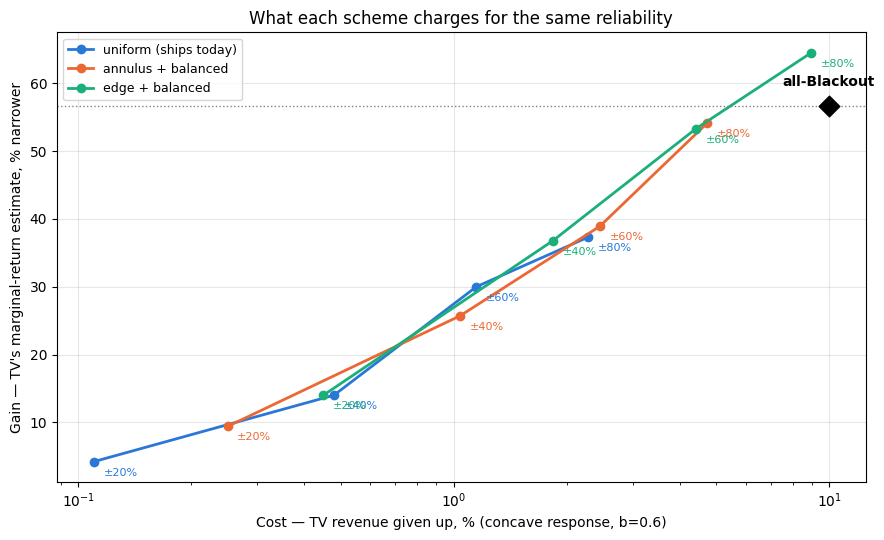

In [9]:
colors = {
    "uniform (ships today)": "#2a78d6",
    "annulus + balanced": "#eb6834",
    "edge + balanced": "#1baf7a",
}

fig, ax = plt.subplots(figsize=(9, 5.5))
for shape, balanced, label in GAIN_SCHEMES:
    sub = tradeoff_df[tradeoff_df["scheme"] == label]
    ax.plot(
        sub["cost (% revenue)"],
        sub["gain (pts narrower)"],
        marker="o",
        color=colors[label],
        label=label,
        linewidth=2,
    )
    for _, r in sub.iterrows():
        ax.annotate(
            r["nominal"],
            (r["cost (% revenue)"], r["gain (pts narrower)"]),
            textcoords="offset points",
            xytext=(7, -10),
            fontsize=8,
            color=colors[label],
        )
ax.scatter([bo_cost], [bo_gain], marker="D", s=110, color="black", zorder=5)
ax.annotate(
    "all-Blackout",
    (bo_cost, bo_gain),
    textcoords="offset points",
    xytext=(0, 14),
    ha="center",
    fontsize=10,
    fontweight="bold",
)
ax.axhline(bo_gain, color="grey", linestyle=":", linewidth=1)
ax.set_xscale("log")
ax.set_xlabel(f"Cost — TV revenue given up, % (concave response, b={B_MAIN})")
ax.set_ylabel("Gain — TV's marginal-return estimate, % narrower")
ax.set_title("What each scheme charges for the same reliability")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Reading the chart

**The three continuous schemes lie almost on top of each other.** Once cost is on the axis, changing the shape mostly moves you *along* one frontier rather than shifting the frontier outwards. Matching on gain rather than on the nominal setting:

| gain | cheapest way to buy it | cost |
|---|---|---|
| ~37 points | `edge + balanced` ±40% | **1.84%** |
| | uniform ±80% | 2.28% |
| ~54 points | `edge + balanced` ±60% | **4.42%** |
| | `annulus + balanced` ±80% | 4.73% |

So the shapes are worth roughly 20% off the bill for a given amount of reliability. Real, but modest — and much less dramatic than section 2's "three times the gain at the same setting", which is true only because the *setting* is not the thing that costs money. The realised movement is, and that is what the shapes increase.

**Where the shapes genuinely help is operational, not financial.** `edge + balanced` reaches the same reliability as uniform ±80% while asking the planner for ±40%. Halving the number you have to get signed off, at slightly lower revenue cost, is worth having even where the frontier is flat.

**The one option that is off the frontier is all-Blackout.** It sits well to the right of every continuous scheme at the same gain: 56.7 points for 9.98%, where `edge + balanced` ±60% buys 53.3 for 4.42% and ±80% buys 64.5 for 8.96%. There is no amplitude at which going dark is the efficient way to buy reliability here. That, not the choice of shape, is this notebook's finding.

## What this notebook concludes

**1. The shipped draw wastes most of the permission it is given.** It spends 41–43% of the negotiated band; a ±20% permission moves a typical week by 8.3%. `annulus` and `edge` with `balance_signs=True` spend 70% and 93% of it, and — balanced — are *better contained* than the current draw at every setting tested (worst realised deviation 1.36–1.66× nominal against uniform's 1.65–2.59×). That is two to three times the reliability gain at the same signed-off setting.

**2. But at equal cost the shapes are worth about 20%, not 200%.** Reliability is bought with realised movement, and realised movement is what costs revenue, so raising the shape mostly moves you along one frontier. `edge + balanced` ±40% buys the same 37 points as uniform ±80% for 1.84% against 2.28%. The bigger practical win is that it needs a ±40% sign-off rather than ±80%.

**3. The saturation objection to edge-drawing does not hold.** Bias against a concave truth never gets worse than doing nothing, because each week moves by a percentage of its *own* plan and the plan already spans a 3.7× range. Precision improves 70% with accuracy unchanged.

**4. There is a real cost and it is revenue, not accuracy.** Under a concave response, preserving the monthly total is not the same as preserving the month's revenue — Jensen, exact. At `b=0.6` all-Blackout gives up 9.98% of TV's contribution, and the package has never reported it.

**5. all-Blackout is off the frontier, and that is the headline.** 5.7 points per 1% of revenue against 20–37 for the continuous levers at ±20–40%. `annulus + balanced` ±80% gets 54.1 points against Blackout's 56.7 for less than half the cost, with no dark weeks. Its cost is also the least knowable of any option: a dark week's price depends on how sharply the curve bends near zero, the one region a continuous lever never visits, and across the `b` range tested Blackout's bill nearly triples where the continuous levers' barely move.

**6. There is no interior optimum.** Cost is roughly quadratic in amplitude where gain is closer to linear, so points-per-% falls monotonically. The decision is "the smallest amplitude that reaches the precision you need" — and this is the first version of the package able to say what that costs.

### What still has to be true before any of this reaches the page

- **The concavity is assumed, not measured.** Publish as a sensitivity band across plausible `b`, never a point estimate — the treatment `chartCorrCost` already gives correlation. Blackout especially.
- **The gain numbers are at `n_sims=50` and 8 phasing seeds.** Fine for ranking schemes, thin for publishing a figure.
- **One channel, one scenario, one seed set.** Both curves should hold across correlation levels and channel counts before the page's argument is rewritten around them.
- **The cap is still not enforced after the rescale.** Any recommendation to use `annulus`/`edge` in front of a hard external ceiling — an ad platform's ±20%, say — needs a repair step the package does not have.
- **Nothing here measures what a client actually feels.** Revenue given up is modelled, not observed; the operational cost of a dark week or a jagged plan is not modelled at all.